Tables created : employees, departments

ROLAP Results:
    department  avg_salary
0  Engineering     85000.0
1           HR     90000.0
2        Sales    100000.0


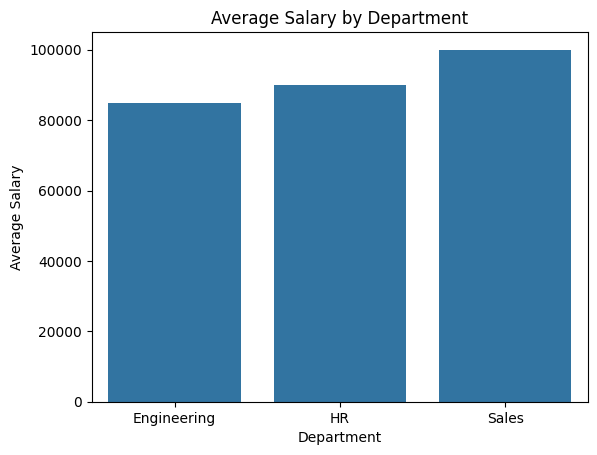


MOLAP Cube:
age_group    Young   Mid-age    Senior
dep_id                                
1          70000.0       NaN  110000.0
2          80000.0   90000.0       NaN
3              NaN  100000.0       NaN


C:\Users\USER\AppData\Local\Temp\ipykernel_29524\3642684123.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  molap_cube = pd.pivot_table(
C:\Users\USER\AppData\Local\Temp\ipykernel_29524\3642684123.py:62: FutureWarning: The provided callable <function mean at 0x0000015458A37560> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  molap_cube = pd.pivot_table(


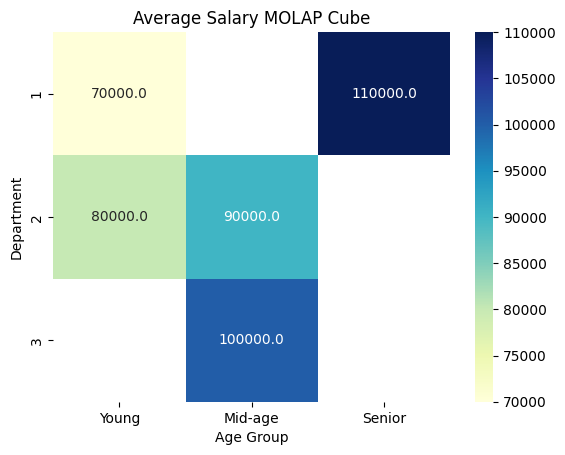


HOLAP Summary (Average Salary by Department):
      dep_name    salary
0  Engineering   85000.0
1           HR   90000.0
2        Sales  100000.0


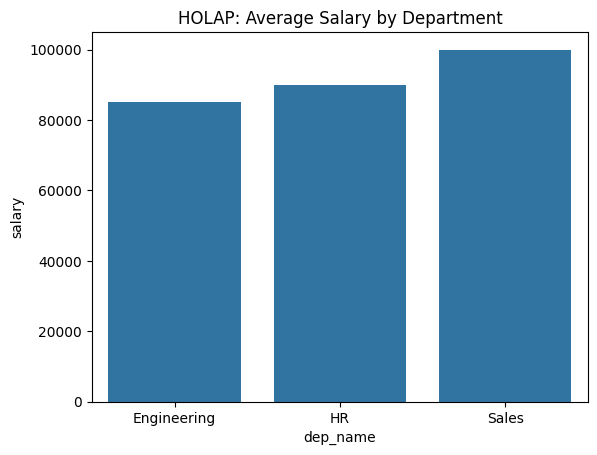


Slice (Engineering Department):
      name     dep_name  salary
1      Bob  Engineering   80000
2  Charlie  Engineering   90000

Dice (HR Department with Salary > 60000):
    name dep_name  salary
0  Alice       HR   70000
4    Eva       HR  110000


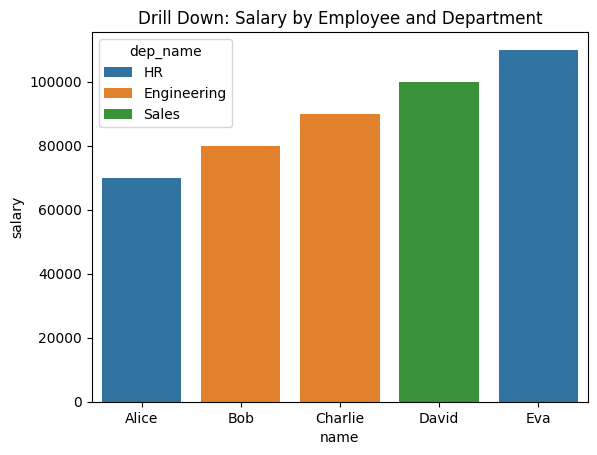


Roll Up (Total Salary by Department):
      dep_name  salary
0  Engineering  170000
1           HR  180000
2        Sales  100000


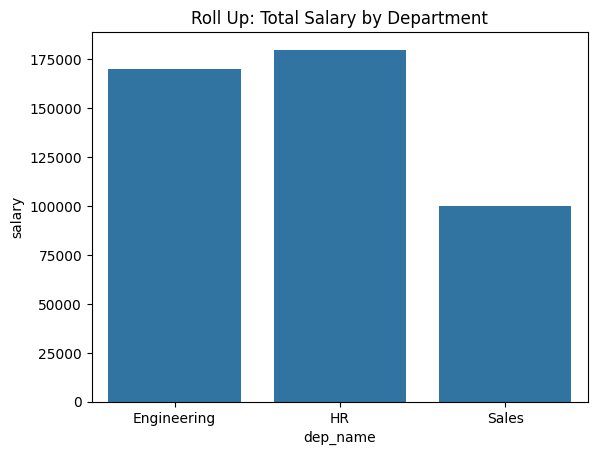

In [8]:
# Rolap Demo

import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# database connection
def create_connection(db_file=":memory:"):
    conn = sqlite3.connect(db_file)
    return conn

# create sample employees table with dep_id
employees = pd.DataFrame({
    'id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'age': [30, 35, 40, 45, 50],
    'salary': [70000, 80000, 90000, 100000, 110000],
    'dep_id': [1, 2, 2, 3, 1]  # Added department IDs
})

departments = pd.DataFrame({
    'dep_id': [1, 2, 3],
    'dep_name': ['HR', 'Engineering', 'Sales']
})

# load into sqlite3
conn = create_connection()
employees.to_sql('employees', conn, if_exists='replace', index=False)
departments.to_sql('departments', conn, if_exists='replace', index=False)
print("Tables created : employees, departments")

# Perform OLAP operations
# ROLAP operations
query = """
SELECT d.dep_name as department, AVG(e.salary) as avg_salary
FROM employees e
JOIN departments d ON e.dep_id = d.dep_id
GROUP BY d.dep_name
"""

rolap_results = pd.read_sql_query(query, conn)
print("\nROLAP Results:")
print(rolap_results)

# VISUALIZATION : Rolap by department
sns.barplot(x='department', y='avg_salary', data=rolap_results)
plt.title('Average Salary by Department')   
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.show()

# MOLAP operations (pivot table in pandas)
# First, create an age group
employees['age_group'] = pd.cut(
    employees['age'],
    bins=[20, 35, 45, 60],
    labels=['Young', 'Mid-age', 'Senior']
)

molap_cube = pd.pivot_table(
    employees,
    values='salary',
    index=['dep_id'],
    columns=['age_group'],
    aggfunc=np.mean
)

print("\nMOLAP Cube:")
print(molap_cube)

# VISUALIZATION : Molap by department
sns.heatmap(molap_cube, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Average Salary MOLAP Cube')
plt.xlabel('Age Group')
plt.ylabel('Department')
plt.show()

# HOLAP Operations
# Combining ROLAP and MOLAP approaches

detail_sql = """
SELECT e.name, d.dep_name, e.salary
FROM employees e
JOIN departments d ON e.dep_id = d.dep_id
"""
detail_df = pd.read_sql_query(detail_sql, conn)

# pandas MOLAP aggregation
holap_summary = detail_df.groupby('dep_name')['salary'].mean().reset_index()

print("\nHOLAP Summary (Average Salary by Department):")
print(holap_summary)

# visualization : HOLAP summary
sns.barplot(data=holap_summary, x='dep_name', y='salary')
plt.title("HOLAP: Average Salary by Department")
plt.show()

# OLAP operations demonstrated: ROLAP, MOLAP, HOLAP

# Slice (example: Engineering Department)
slice_df = detail_df[detail_df['dep_name'] == 'Engineering']
print("\nSlice (Engineering Department):")
print(slice_df)

# Dice (HR Department with Salary > 60000)
dice_df = detail_df[(detail_df['dep_name'] == 'HR') & (detail_df['salary'] > 60000)]
print("\nDice (HR Department with Salary > 60000):")
print(dice_df)

# Drill down
sns.barplot(data=detail_df, x='name', y='salary', hue='dep_name')
plt.title("Drill Down: Salary by Employee and Department")
plt.show()

# Roll up
rollup_df = detail_df.groupby('dep_name')['salary'].sum().reset_index()
print("\nRoll Up (Total Salary by Department):")
print(rollup_df)

# visualization : rollup
sns.barplot(data=rollup_df, x='dep_name', y='salary')
plt.title("Roll Up: Total Salary by Department")
plt.show()
